# Descargar MDT

In [33]:
import rasterio
from rasterio.io import MemoryFile
from rasterio.merge import merge
from rasterio.features import geometry_mask
import requests
from math import ceil
import geopandas as gpd
import numpy as np
from time import sleep

# Cargar el GeoDataFrame
gdf = gpd.read_file('test.gpkg')

print(f"📍 GeoDataFrame cargado:")
print(f"  - Filas: {len(gdf)}")
print(f"  - CRS: {gdf.crs}")
print(f"  - Bounds: {gdf.total_bounds}\n")

# Asegurar que está en EPSG:4326 (WGS84)
if gdf.crs.to_epsg() != 4326:
    print(f"⚠️ Reproyectando de {gdf.crs} a EPSG:4326...")
    gdf = gdf.to_crs(epsg=4326)

# Obtener el bbox del GeoDataFrame
minx, miny, maxx, maxy = gdf.total_bounds

# Parámetros del servicio
base = "https://api-coverages.idee.es"
coverage_id = "EL.ElevationGridCoverage_4258_5_PB"
MAX_TILE_SIZE = 0.01  # 1 km

# Calcular número de tiles necesarios
width = maxx - minx
height = maxy - miny
n_tiles_x = ceil(width / MAX_TILE_SIZE)
n_tiles_y = ceil(height / MAX_TILE_SIZE)
total_tiles = n_tiles_x * n_tiles_y

print(f"🔲 Área total: {width:.6f}° x {height:.6f}°")
print(f"📦 Dividiendo en {n_tiles_x} x {n_tiles_y} = {total_tiles} tiles")
print(f"📏 Tamaño de tile: {MAX_TILE_SIZE}° (~{MAX_TILE_SIZE*111:.1f} km)\n")

# Función para descargar con reintentos
def get_with_retry(url, retries=3, timeout=120):
    """Descarga con reintentos automáticos en caso de error 500"""
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=timeout)
            if r.status_code == 200:
                return r
            elif r.status_code == 500:
                print(f"⚠️ Error 500, reintento {attempt+1}/{retries}...")
                if attempt < retries - 1:
                    sleep(3)  # Espera más tiempo
            else:
                return r
        except Exception as e:
            print(f"⚠️ Excepción: {e}, reintento {attempt+1}/{retries}...")
            if attempt < retries - 1:
                sleep(3)
    return r

# Descargar tiles
tiles_data = []  # Lista de tuplas (array, transform, crs, nodata)

for i in range(n_tiles_x):
    for j in range(n_tiles_y):
        tile_minx = minx + i * MAX_TILE_SIZE
        tile_maxx = min(tile_minx + MAX_TILE_SIZE, maxx)
        tile_miny = miny + j * MAX_TILE_SIZE
        tile_maxy = min(tile_miny + MAX_TILE_SIZE, maxy)
        
        tile_num = i * n_tiles_y + j + 1
        print(f"⬇️  Tile {tile_num}/{total_tiles} [{tile_minx:.5f},{tile_miny:.5f},{tile_maxx:.5f},{tile_maxy:.5f}]...", end=" ")
        
        cog_url = f"{base}/collections/{coverage_id}/coverage?f=COG&bbox={tile_minx},{tile_miny},{tile_maxx},{tile_maxy}&bbox-crs=4326"
        
        try:
            r = get_with_retry(cog_url)
            
            if r.status_code == 200:
                with MemoryFile(r.content) as memfile:
                    with memfile.open() as src:
                        # Guardar datos necesarios
                        tiles_data.append({
                            'data': src.read(1),
                            'transform': src.transform,
                            'crs': src.crs,
                            'nodata': src.nodata,
                            'dtype': src.dtypes[0]
                        })
                        print(f"✅ ({src.width}x{src.height} px, {len(r.content)/1024:.1f} KB)")
            else:
                print(f"❌ Error {r.status_code}")
                if r.status_code == 500:
                    print(f"   URL: {cog_url}")
        except Exception as e:
            print(f"❌ Excepción: {e}")

if not tiles_data:
    print("\n❌ No se pudo descargar ningún tile")
else:
    print(f"\n✅ Descargados {len(tiles_data)}/{total_tiles} tiles correctamente\n")
    
    # Obtener metadatos del primer tile
    first_tile = tiles_data[0]
    src_crs = first_tile['crs']
    nodata_value = first_tile['nodata']
    
    print(f"📊 Información del raster:")
    print(f"  - CRS: {src_crs}")
    print(f"  - NoData: {nodata_value}\n")
    
    # Crear datasets temporales para merge
    print("🔗 Uniendo tiles...")
    temp_datasets = []
    temp_memfiles = []  # Mantener referencias para evitar cierre prematuro
    
    for tile_info in tiles_data:
        memfile_temp = MemoryFile()
        temp_memfiles.append(memfile_temp)
        
        temp_dataset = memfile_temp.open(
            driver='GTiff',
            height=tile_info['data'].shape[0],
            width=tile_info['data'].shape[1],
            count=1,
            dtype=tile_info['dtype'],
            crs=tile_info['crs'],
            transform=tile_info['transform'],
            nodata=tile_info['nodata']
        )
        temp_dataset.write(tile_info['data'], 1)
        temp_datasets.append(temp_dataset)
    
    # Merge
    mosaic, mosaic_transform = merge(temp_datasets)
    
    # Cerrar datasets temporales
    for ds in temp_datasets:
        ds.close()
    
    print(f"✅ Mosaico creado: {mosaic.shape}\n")
    
    # Recortar por capa de máscara
    print("✂️  Aplicando máscara de geometría...")
    mask_array = geometry_mask(
        gdf.geometry,
        transform=mosaic_transform,
        invert=True,
        out_shape=(mosaic.shape[1], mosaic.shape[2])
    )
    
    # Aplicar máscara al mosaico
    mosaic = np.where(mask_array, mosaic[0], nodata_value if nodata_value is not None else np.nan)
    
    print(f"✅ Máscara aplicada\n")

📍 GeoDataFrame cargado:
  - Filas: 235
  - CRS: EPSG:25829
  - Bounds: [ 731352.81666744 4491262.37922427  735601.65025143 4495205.18705897]

⚠️ Reproyectando de EPSG:25829 a EPSG:4326...
🔲 Área total: 0.049892° x 0.035462°
📦 Dividiendo en 5 x 4 = 20 tiles
📏 Tamaño de tile: 0.01° (~1.1 km)

⬇️  Tile 1/20 [-6.26757,40.53918,-6.25757,40.54918]... ✅ (223x223 px, 160.3 KB)
⬇️  Tile 2/20 [-6.26757,40.54918,-6.25757,40.55918]... ✅ (223x223 px, 147.5 KB)
⬇️  Tile 3/20 [-6.26757,40.55918,-6.25757,40.56918]... ✅ (223x223 px, 133.5 KB)
⬇️  Tile 4/20 [-6.26757,40.56918,-6.25757,40.57465]... ✅ (223x122 px, 57.5 KB)
⬇️  Tile 5/20 [-6.25757,40.53918,-6.24757,40.54918]... ✅ (223x223 px, 181.0 KB)
⬇️  Tile 6/20 [-6.25757,40.54918,-6.24757,40.55918]... ✅ (223x223 px, 145.8 KB)
⬇️  Tile 7/20 [-6.25757,40.55918,-6.24757,40.56918]... ✅ (223x223 px, 136.6 KB)
⬇️  Tile 8/20 [-6.25757,40.56918,-6.24757,40.57465]... ✅ (223x122 px, 73.6 KB)
⬇️  Tile 9/20 [-6.24757,40.53918,-6.23757,40.54918]... ✅ (222x223 px, 

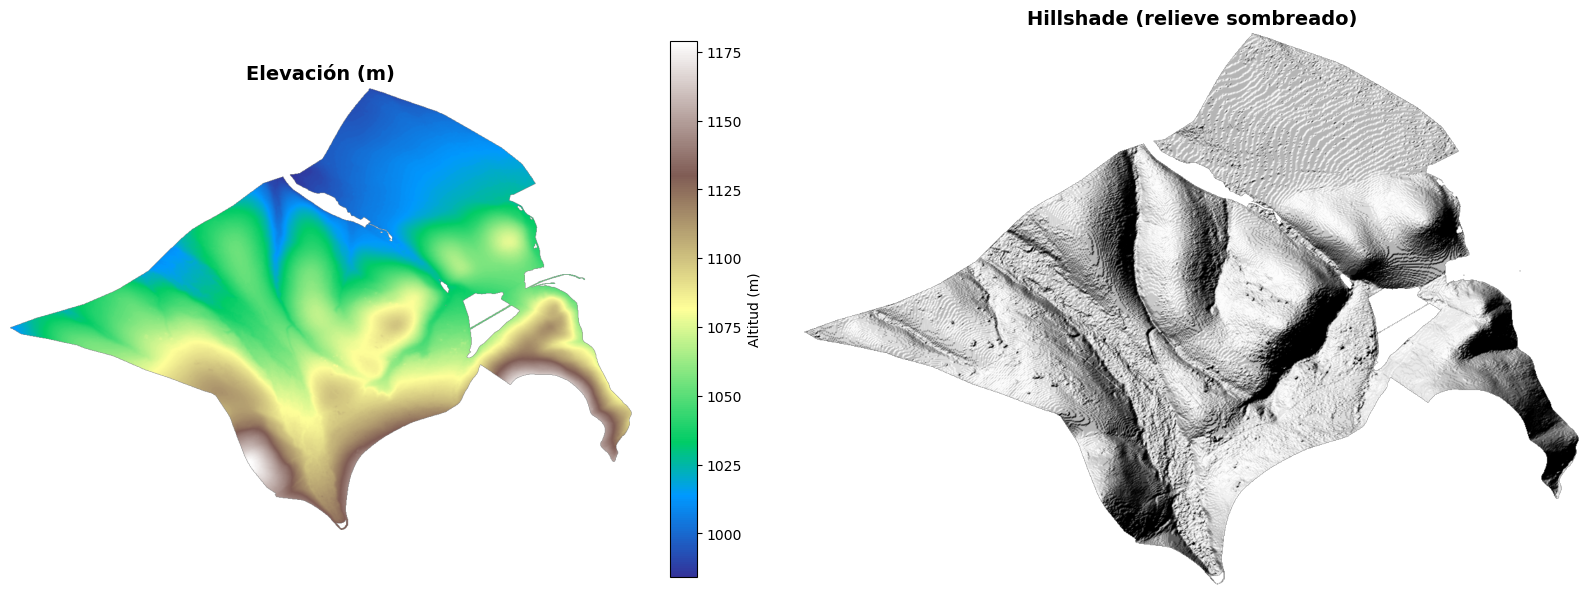


📊 Estadísticos del mosaico:
  - Dimensiones: (788, 1108)
  - Píxeles válidos: 360,714
  - Min: 984.20 m
  - Max: 1179.00 m
  - Media: 1057.66 m
  - Mediana: 1053.52 m


In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# Preparar datos
mosaic_plot = mosaic[0] if mosaic.ndim == 3 else mosaic
if nodata_value is not None:
    mosaic_plot = np.where(mosaic_plot == nodata_value, np.nan, mosaic_plot)

# Crear figura con hillshade
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Mapa de elevación
im1 = ax1.imshow(mosaic_plot, cmap='terrain', interpolation='bilinear')
ax1.set_title('Elevación (m)', fontsize=14, fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, label='Altitud (m)', shrink=0.8)

# Hillshade
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(mosaic_plot, vert_exag=2, dx=1, dy=1)
ax2.imshow(hillshade, cmap='gray', interpolation='bilinear')
ax2.set_title('Hillshade (relieve sombreado)', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Estadísticas
valid_data = mosaic_plot[~np.isnan(mosaic_plot)]
print(f"\n📊 Estadísticos del mosaico:")
print(f"  - Dimensiones: {mosaic_plot.shape}")
print(f"  - Píxeles válidos: {valid_data.size:,}")
print(f"  - Min: {valid_data.min():.2f} m")
print(f"  - Max: {valid_data.max():.2f} m")
print(f"  - Media: {valid_data.mean():.2f} m")
print(f"  - Mediana: {np.median(valid_data):.2f} m")

# NDVI

In [25]:
import requests
import numpy as np
from datetime import datetime, timedelta
from shapely.geometry import mapping
from rasterio.features import geometry_mask
import numpy as np

import geopandas as gpd
import rasterio
from io import BytesIO

gdf = gpd.read_file('geo_preaudit_182add94_20250724.gpkg')

def bbox_from_gdf(gdf: gpd.GeoDataFrame):
    """
    Devuelve bbox [minx, miny, maxx, maxy] en EPSG:4326 a partir del extent del GDF.
    Si el CRS no es 4326, reproyecta.
    """
    if gdf is None or len(gdf) == 0:
        raise ValueError("El GeoDataFrame está vacío.")

    if "geometry" not in gdf.columns:
        raise ValueError("El GeoDataFrame no tiene columna 'geometry'.")

    if gdf.crs is None:
        raise ValueError("El GeoDataFrame no tiene CRS definido (gdf.crs is None). Asigna uno antes.")

    # Reproyectar si no es EPSG:4326
    epsg = gdf.crs.to_epsg()
    if epsg != 4326:
        gdf = gdf.to_crs(epsg=4326)

    minx, miny, maxx, maxy = gdf.total_bounds
    return [float(minx), float(miny), float(maxx), float(maxy)], gdf


def obtener_ndvi_valido(gdf: gpd.GeoDataFrame, dias=90, maxcc=20, width=512, height=512):
    """
    Obtiene NDVI válido usando Sentinel Hub Process API.
    El bbox sale del extent del GDF (en EPSG:4326; reproyecta si hace falta).
    """
    # Nota: no hardcodees credenciales en código; usa variables de entorno si puedes.
    CLIENT_ID = "sh-48cd7ecb-e398-4c07-bf7a-2d0c5df1843e"
    CLIENT_SECRET = "WbAGISqNR6XhHyxmVB2qlmPcbdMaHJGZ"

    bbox, gdf_4326 = bbox_from_gdf(gdf)

    # 1) Token OAuth
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    token_response = requests.post(
        token_url,
        data={
            "grant_type": "client_credentials",
            "client_id": CLIENT_ID,
            "client_secret": CLIENT_SECRET
        },
        timeout=60
    )
    if token_response.status_code != 200:
        raise Exception(f"Error obteniendo token: {token_response.status_code} - {token_response.text}")

    access_token = token_response.json()["access_token"]

    # 2) Fechas
    today = datetime.utcnow()
    start_date = (today - timedelta(days=dias)).strftime("%Y-%m-%d")
    end_date = today.strftime("%Y-%m-%d")

    # 3) Process API
    process_url = "https://sh.dataspace.copernicus.eu/api/v1/process"

    evalscript = """
    //VERSION=3
    function setup() {
        return {
            input: [{
                bands: ["B04", "B08", "SCL"],
                units: "DN"
            }],
            output: {
                bands: 1,
                sampleType: "FLOAT32"
            }
        };
    }

    function evaluatePixel(sample) {
        // SCL: 3=sombra, 8=nube media, 9=nube alta, 10=cirrus, 11=nieve/hielo
        if ([3, 8, 9, 10, 11].includes(sample.SCL)) {
            return [NaN];
        }
        let denom = (sample.B08 + sample.B04);
        if (denom === 0) return [NaN];
        let ndvi = (sample.B08 - sample.B04) / denom;
        return [ndvi];
    }
    """

    payload = {
        "input": {
            "bounds": {
                "bbox": bbox,
                "properties": {"crs": "http://www.opengis.net/def/crs/EPSG/0/4326"}
            },
            "data": [{
                "type": "sentinel-2-l2a",
                "dataFilter": {
                    "timeRange": {
                        "from": f"{start_date}T00:00:00Z",
                        "to": f"{end_date}T23:59:59Z"
                    },
                    "maxCloudCoverage": maxcc,
                    "mosaickingOrder": "leastCC"
                }
            }]
        },
        "output": {
            "width": int(width),
            "height": int(height),
            "responses": [{
                "identifier": "default",
                "format": {"type": "image/tiff"}
            }]
        },
        "evalscript": evalscript
    }

    headers = {
        "Authorization": f"Bearer {access_token}",
        "Content-Type": "application/json"
    }

    response = requests.post(process_url, json=payload, headers=headers, timeout=120)
    if response.status_code != 200:
        raise Exception(f"Error Process API {response.status_code}: {response.text}")

    # 4) Leer TIFF
    with rasterio.open(BytesIO(response.content)) as src:
        ndvi_array = src.read(1)
        transform = src.transform
        raster_crs = src.crs  # debería venir en el GeoTIFF

    # 1) Asegura que la máscara (gdf) está en el mismo CRS que el raster
    gdf_mask = gdf_4326
    if raster_crs is not None and gdf_mask.crs != raster_crs:
        gdf_mask = gdf_mask.to_crs(raster_crs)

    # 2) Unir geometrías (una sola máscara)
    geom = gdf_mask.geometry.unary_union  # geopandas<1.0
    # Si usas geopandas>=1.0 puedes usar: geom = gdf_mask.geometry.union_all()

    # 3) Crear máscara booleana: True = dentro del polígono, False = fuera
    inside = geometry_mask(
        [mapping(geom)],
        out_shape=ndvi_array.shape,
        transform=transform,
        invert=True,          # invert=True => True dentro
        all_touched=False     # pon True si quieres ser más “permisivo” en bordes
    )

    # 4) Poner NaN fuera del polígono
    ndvi_array = np.where(inside, ndvi_array, np.nan)

    # 5) (Opcional) ahora ya aplicas tu máscara de valores válidos como antes
    valid_mask = (
        ~np.isnan(ndvi_array) &
        ~np.isinf(ndvi_array) &
        (ndvi_array >= -1) &
        (ndvi_array <= 1)
    )
    valid_ndvi = ndvi_array[valid_mask]
    ndvi_2d = np.where(valid_mask, ndvi_array, np.nan)

    if valid_ndvi.size == 0:
        return None, None, None, bbox

    stats = {
        "mean": float(valid_ndvi.mean()),
        "median": float(np.median(valid_ndvi)),
        "std": float(valid_ndvi.std()),
        "min": float(valid_ndvi.min()),
        "max": float(valid_ndvi.max()),
        "count": int(valid_ndvi.size),
        "coverage": float(valid_ndvi.size / ndvi_array.size * 100),
        "date_range": f"{start_date} a {end_date}",
        "bbox_4326": bbox
    }

    return valid_ndvi, ndvi_2d, stats, bbox


# Ejemplo de uso:
# gdf = gpd.read_file("mi_poligono.gpkg")  # o el que sea
valid_ndvi, ndvi_2d, stats, bbox = obtener_ndvi_valido(gdf, dias=90, maxcc=50)

✓ Visualización guardada como 'ndvi_analysis.png'


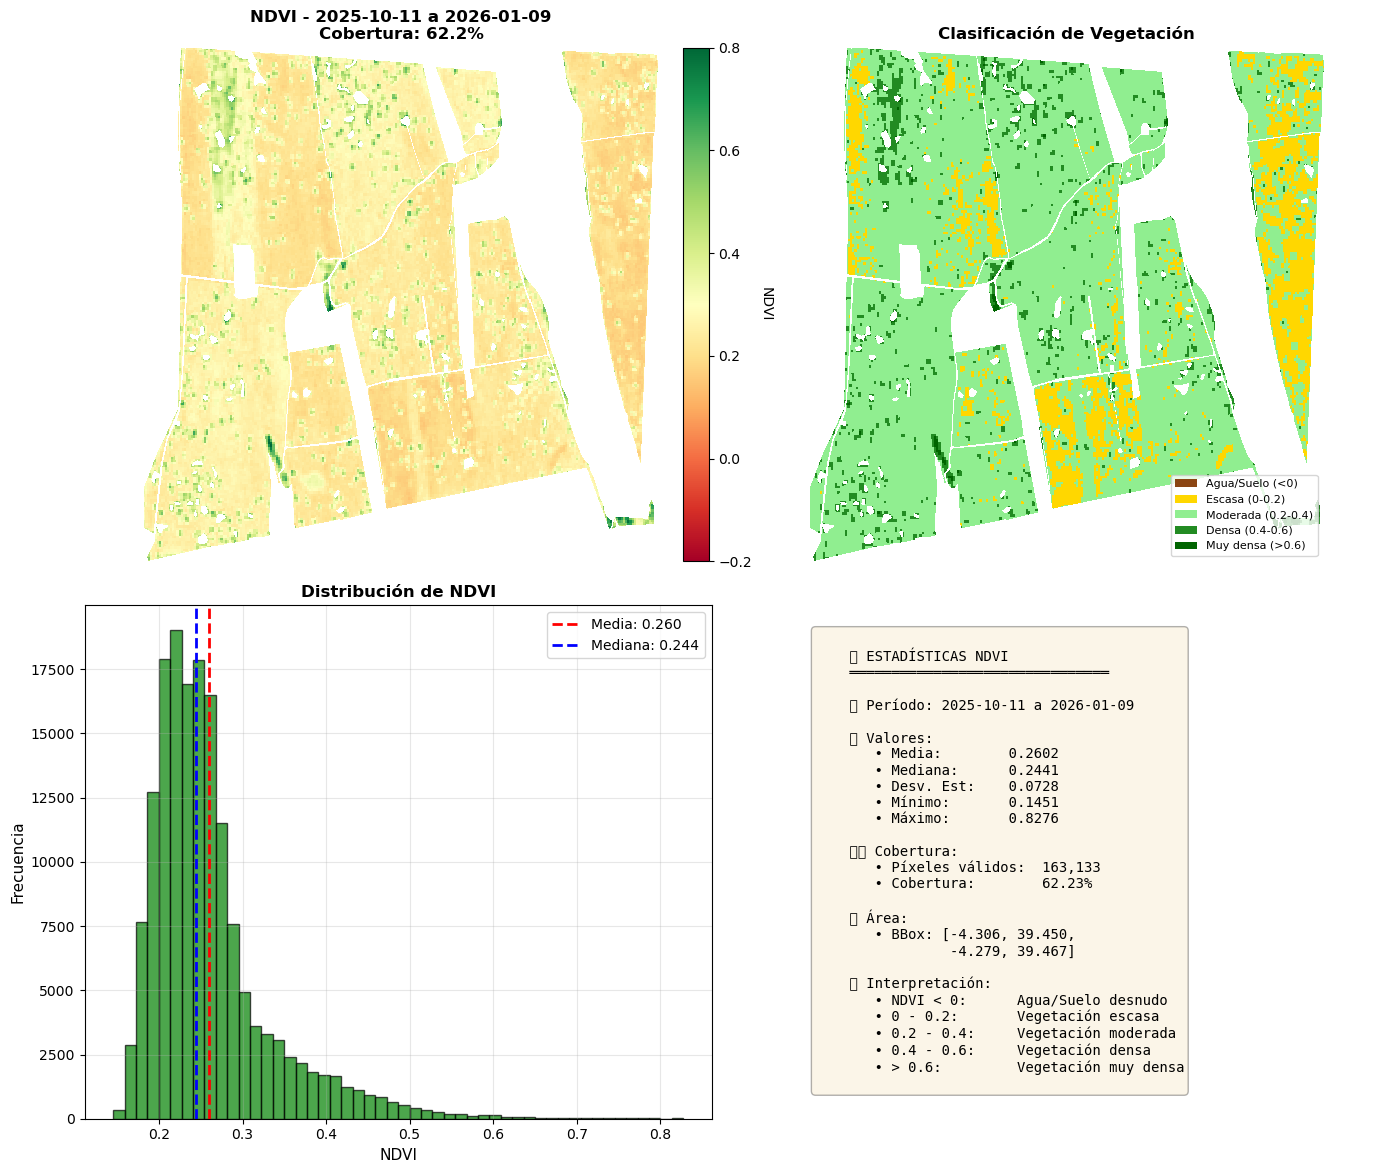

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

def visualizar_ndvi(ndvi_2d, valid_ndvi, stats, bbox):
    """
    Visualiza el NDVI en múltiples formatos
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Mapa de calor NDVI
    ax1 = axes[0, 0]
    im1 = ax1.imshow(ndvi_2d, cmap='RdYlGn', vmin=-0.2, vmax=0.8, interpolation='nearest')
    ax1.set_title(f'NDVI - {stats["date_range"]}\nCobertura: {stats["coverage"]:.1f}%', 
                  fontsize=12, fontweight='bold')
    ax1.axis('off')
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('NDVI', rotation=270, labelpad=15)
    
    # 2. Clasificación de vegetación
    ax2 = axes[0, 1]
    ndvi_classified = np.full_like(ndvi_2d, np.nan)
    ndvi_classified[ndvi_2d < 0] = 0      # Agua/suelo desnudo
    ndvi_classified[(ndvi_2d >= 0) & (ndvi_2d < 0.2)] = 1  # Vegetación escasa
    ndvi_classified[(ndvi_2d >= 0.2) & (ndvi_2d < 0.4)] = 2  # Vegetación moderada
    ndvi_classified[(ndvi_2d >= 0.4) & (ndvi_2d < 0.6)] = 3  # Vegetación densa
    ndvi_classified[ndvi_2d >= 0.6] = 4   # Vegetación muy densa
    
    colors = ['#8B4513', '#FFD700', '#90EE90', '#228B22', '#006400']
    cmap_class = plt.matplotlib.colors.ListedColormap(colors)
    im2 = ax2.imshow(ndvi_classified, cmap=cmap_class, vmin=0, vmax=4, interpolation='nearest')
    ax2.set_title('Clasificación de Vegetación', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    # Leyenda personalizada
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#8B4513', label='Agua/Suelo (<0)'),
        Patch(facecolor='#FFD700', label='Escasa (0-0.2)'),
        Patch(facecolor='#90EE90', label='Moderada (0.2-0.4)'),
        Patch(facecolor='#228B22', label='Densa (0.4-0.6)'),
        Patch(facecolor='#006400', label='Muy densa (>0.6)')
    ]
    ax2.legend(handles=legend_elements, loc='lower right', fontsize=8)
    
    # 3. Histograma
    ax3 = axes[1, 0]
    ax3.hist(valid_ndvi, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax3.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Media: {stats['mean']:.3f}")
    ax3.axvline(stats['median'], color='blue', linestyle='--', linewidth=2, label=f"Mediana: {stats['median']:.3f}")
    ax3.set_xlabel('NDVI', fontsize=11)
    ax3.set_ylabel('Frecuencia', fontsize=11)
    ax3.set_title('Distribución de NDVI', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Estadísticas textuales
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    stats_text = f"""
    📊 ESTADÍSTICAS NDVI
    ═══════════════════════════════
    
    📅 Período: {stats['date_range']}
    
    📈 Valores:
       • Media:        {stats['mean']:.4f}
       • Mediana:      {stats['median']:.4f}
       • Desv. Est:    {stats['std']:.4f}
       • Mínimo:       {stats['min']:.4f}
       • Máximo:       {stats['max']:.4f}
    
    🗺️ Cobertura:
       • Píxeles válidos:  {stats['count']:,}
       • Cobertura:        {stats['coverage']:.2f}%
    
    📍 Área:
       • BBox: [{bbox[0]:.3f}, {bbox[1]:.3f}, 
                {bbox[2]:.3f}, {bbox[3]:.3f}]
    
    🌱 Interpretación:
       • NDVI < 0:      Agua/Suelo desnudo
       • 0 - 0.2:       Vegetación escasa
       • 0.2 - 0.4:     Vegetación moderada
       • 0.4 - 0.6:     Vegetación densa
       • > 0.6:         Vegetación muy densa
    """
    
    ax4.text(0.1, 0.95, stats_text, transform=ax4.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig('ndvi_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización guardada como 'ndvi_analysis.png'")
    plt.show()


# Usar la función
if valid_ndvi is not None:
    visualizar_ndvi(ndvi_2d, valid_ndvi, stats, bbox)
else:
    print("⚠️ No hay datos para visualizar")

# SOIL

In [ ]:
import re
import requests
import numpy as np
import rasterio
from rasterio.io import MemoryFile
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
import geopandas as gpd

WCS_VERSION = "2.0.1"

PROP_TO_MAP = {
    "clay": "https://maps.isric.org/mapserv?map=/map/clay.map",
    "sand": "https://maps.isric.org/mapserv?map=/map/sand.map",
    "silt": "https://maps.isric.org/mapserv?map=/map/silt.map",
}

def get_capabilities_xml(prop: str) -> str:
    url = PROP_TO_MAP[prop]
    params = {"service": "WCS", "request": "GetCapabilities", "version": WCS_VERSION}
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    return r.text

def find_coverage_id(cap_xml: str, prop: str, depth: str, stat: str) -> str:
    """
    Busca coverageId tipo: 'clay_0-5cm_mean' o 'clay_0-5cm_Q0.5'
    """
    target = f"{prop}_{depth}_{stat}"
    ids = re.findall(r"<[^>]*CoverageId[^>]*>\s*([^<\s]+)\s*</", cap_xml)
    if target in ids:
        return target

    cand = [i for i in ids if i.lower() == target.lower()]
    if cand:
        return cand[0]

    raise ValueError(
        f"No encontré coverageId '{target}'. "
        f"Ejemplos disponibles: {ids[:10]} ... (total {len(ids)})"
    )

def download_wcs_array(prop: str, coverage_id: str, bbox4326):
    """
    Descarga GeoTIFF vía WCS y devuelve (array, profile) en memoria.
    bbox4326 = (minLon, minLat, maxLon, maxLat)
    """
    minx, miny, maxx, maxy = bbox4326
    base = PROP_TO_MAP[prop]
    params = {
        "service": "WCS",
        "request": "GetCoverage",
        "version": WCS_VERSION,
        "coverageId": coverage_id,
        "format": "GEOTIFF_INT16",
        "subset": [f"X({minx},{maxx})", f"Y({miny},{maxy})"],
        "subsettingCrs": "http://www.opengis.net/def/crs/EPSG/0/4326",
        "outputCrs": "http://www.opengis.net/def/crs/EPSG/0/4326",
    }
    r = requests.get(base, params=params, timeout=300)
    r.raise_for_status()

    # leer desde memoria
    with MemoryFile(r.content) as memfile:
        with memfile.open() as ds:
            arr = ds.read(1).astype(np.float32)
            profile = ds.profile
            nodata = ds.nodata

    # manejar nodata (típicamente -32768 en INT16)
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    return arr, profile

def resample_array_to_match(src_arr, src_profile, ref_profile):
    """
    Re-muestrea src_arr para que coincida con ref (shape/transform/crs).
    Devuelve array re-muestreado.
    """
    dst = np.empty((ref_profile["height"], ref_profile["width"]), dtype=src_arr.dtype)

    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_profile["transform"],
        src_crs=src_profile["crs"],
        dst_transform=ref_profile["transform"],
        dst_crs=ref_profile["crs"],
        resampling=Resampling.bilinear,
    )
    return dst

def gdf_to_bbox4326(gdf: gpd.GeoDataFrame):
    """
    Extrae bbox (minLon, minLat, maxLon, maxLat) en EPSG:4326.
    Si gdf no está en 4326, lo reproyecta.
    """
    if gdf.crs is None:
        raise ValueError("GeoDataFrame sin CRS definido. Asigna uno con gdf.set_crs(...)")

    if gdf.crs.to_epsg() != 4326:
        print(f"Reproyectando de {gdf.crs} a EPSG:4326...")
        gdf = gdf.to_crs(epsg=4326)

    bounds = gdf.total_bounds  # (minx, miny, maxx, maxy)
    return tuple(bounds)

def williams_k(sand_pct, silt_pct, clay_pct):
    """
    Factor K de Williams (1975).
    Entradas en % (0-100).
    Salida: K en t·h/(MJ·mm)
    """
    SN1 = 1.0 - (sand_pct / 100.0)

    term1 = 0.2 + 0.3 * np.exp(-0.0256 * sand_pct * (1.0 - (silt_pct / 100.0)))
    term2 = 1.0 - (0.25 * clay_pct / (clay_pct + np.exp(3.72 - 2.95 * clay_pct)))
    term3 = 1.0 - (0.7 * SN1 / (SN1 + np.exp(-5.51 + 22.9 * SN1)))

    return term1 * term2 * term3

def calculate_factor_K_williams(gdf: gpd.GeoDataFrame, depth="0-5cm", stat="mean"):
    """
    Calcula el Factor K (erodibilidad del suelo) usando Williams (1975).

    Args:
        gdf: GeoDataFrame con geometría(s) para definir ROI (bbox).
        depth: profundidad SoilGrids (ej: "0-5cm", "5-15cm", ...).
        stat: estadístico ("mean", "Q0.5", "Q0.05", "Q0.95").

    Returns:
        dict con:
            - 'sand': array (g/kg)
            - 'silt': array (g/kg)
            - 'clay': array (g/kg)
            - 'sand_pct': array (%)
            - 'silt_pct': array (%)
            - 'clay_pct': array (%)
            - 'K': array (t·h/(MJ·mm))
            - 'profile': rasterio profile (metadatos geoespaciales)
    """
    # 1) extraer bbox en EPSG:4326
    bbox = gdf_to_bbox4326(gdf)
    print(f"Bbox EPSG:4326: {bbox}")

    # 2) descubrir coverageIds
    cov = {}
    for prop in ["sand", "silt", "clay"]:
        cap = get_capabilities_xml(prop)
        cov[prop] = find_coverage_id(cap, prop, depth, stat)
        print(f"{prop}: coverageId = {cov[prop]}")

    # 3) descargar arrays en memoria
    sand_arr, sand_prof = download_wcs_array("sand", cov["sand"], bbox)
    silt_arr, silt_prof = download_wcs_array("silt", cov["silt"], bbox)
    clay_arr, clay_prof = download_wcs_array("clay", cov["clay"], bbox)

    # 4) asegurar misma grilla (usar sand como referencia)
    def profiles_match(p1, p2):
        return (p1["width"] == p2["width"] and p1["height"] == p2["height"]
                and p1["transform"] == p2["transform"] and p1["crs"] == p2["crs"])

    if not profiles_match(silt_prof, sand_prof):
        print("Re-muestreando silt a grilla de sand...")
        silt_arr = resample_array_to_match(silt_arr, silt_prof, sand_prof)

    if not profiles_match(clay_prof, sand_prof):
        print("Re-muestreando clay a grilla de sand...")
        clay_arr = resample_array_to_match(clay_arr, clay_prof, sand_prof)

    # 5) convertir g/kg → % (SoilGrids usa g/kg, 0-1000)
    sand_pct = sand_arr / 10.0
    silt_pct = silt_arr / 10.0
    clay_pct = clay_arr / 10.0

    # 6) calcular K
    k = williams_k(sand_pct, silt_pct, clay_pct)

    # máscara nodata
    mask = np.isfinite(sand_pct) & np.isfinite(silt_pct) & np.isfinite(clay_pct)
    k = np.where(mask, k, np.nan)

    return {
        "sand": sand_arr,       # g/kg
        "silt": silt_arr,       # g/kg
        "clay": clay_arr,       # g/kg
        "sand_pct": sand_pct,   # %
        "silt_pct": silt_pct,   # %
        "clay_pct": clay_pct,   # %
        "K": k,                 # t·h/(MJ·mm)
        "profile": sand_prof,   # metadatos raster (CRS, transform, etc.)
    }

# ============ EJEMPLO DE USO ============
if __name__ == "__main__":
    gdf = gpd.read_file('test.gpkg')

    # Calcular K
    result = calculate_factor_K_williams(gdf, depth="0-5cm", stat="mean")

    print(f"\nK shape: {result['K'].shape}")
    print(f"K min/max: {np.nanmin(result['K']):.4f} / {np.nanmax(result['K']):.4f}")
    print(f"K mean: {np.nanmean(result['K']):.4f}")

Reproyectando de EPSG:25829 a EPSG:4326...
Bbox EPSG:4326: (np.float64(-6.2675658012965805), np.float64(40.539183431591596), np.float64(-6.217674274864749), np.float64(40.57464510349304))
sand: coverageId = sand_0-5cm_mean
silt: coverageId = silt_0-5cm_mean
clay: coverageId = clay_0-5cm_mean

K shape: (15, 22)
K min/max: 0.2312 / 0.2560
K mean: 0.2440


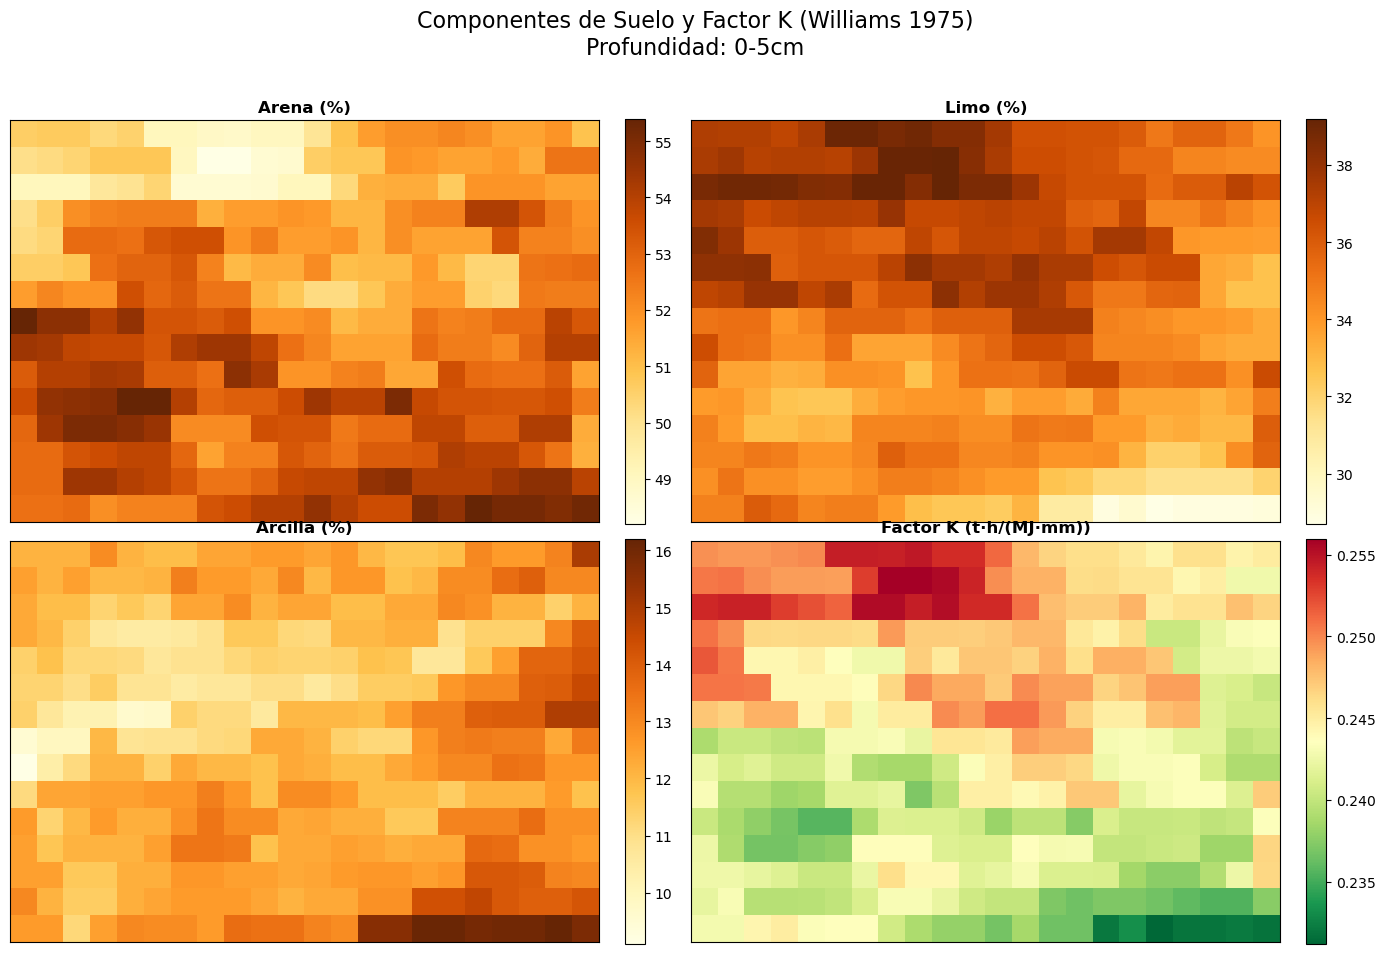

In [29]:
import matplotlib.pyplot as plt

def visualize_k_components(result):
    """
    Visualiza los componentes de textura (%) y el Factor K resultante.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Componentes de Suelo y Factor K (Williams 1975)\nProfundidad: 0-5cm", fontsize=16)

    # Configuración de las capas a mostrar
    layers = [
        ('sand_pct', 'Arena (%)', 'YlOrBr'),
        ('silt_pct', 'Limo (%)', 'YlOrBr'),
        ('clay_pct', 'Arcilla (%)', 'YlOrBr'),
        ('K', 'Factor K (t·h/(MJ·mm))', 'RdYlGn_r') # _r para que rojo sea K alto (más erosión)
    ]

    for i, (key, title, cmap) in enumerate(layers):
        ax = axes[i // 2, i % 2]
        data = result[key]
        
        # Mostrar imagen
        im = ax.imshow(data, cmap=cmap)
        ax.set_title(title, fontweight='bold')
        
        # Añadir barra de color
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Quitar ticks para limpieza visual
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Ejecución ---
visualize_k_components(result)

# Factor R

In [40]:
import cdsapi
import pandas as pd
import numpy as np
import xarray as xr
import zipfile
import os

LAT = 40.4168
LON = -3.7038

# Últimos 15 años completos
end_year = 2024
start_year = 2010
years = [str(y) for y in range(start_year, end_year + 1)]

# Área de descarga (N, W, S, E)
d = 0.1
area = [LAT + d, LON - d, LAT - d, LON + d]

# Archivo temporal
target = 'temp.grib'

try:
    # ========== DESCARGA ==========
    client = cdsapi.Client(
        url="https://cds.climate.copernicus.eu/api",
        key="7314d9c0-2468-4f66-8d21-1bea09c0bccf"
    )
    
    
    dataset = "reanalysis-era5-land-monthly-means"
    request = {
        "product_type": ["monthly_averaged_reanalysis"],
        "variable": ["total_precipitation"],
        "year": years,
        "month": [f"{m:02d}" for m in range(1, 13)],
        "time": ["00:00"],
        "area": area,
        "data_format": "grib",
        "download_format": "unarchived",
    }
    
    print("Descargando datos...")
    client.retrieve(dataset, request, target)
    print("Descarga completada.")
    
    # ========== EXTRACCIÓN SI ES ZIP ==========
    with open(target, "rb") as f:
        head = f.read(4)
    
    if head == b"PK\x03\x04":
        with zipfile.ZipFile(target, "r") as z:
            names = z.namelist()
            print("ZIP contiene:", names)
            grib_name = [n for n in names if n.lower().endswith(".grib")][0]
            z.extract(grib_name, ".")
        grib_path = grib_name
    else:
        grib_path = target
    
    # ========== ABRIR AMBOS TIPOS DE GRIB ==========
    print("\nAbriendo GRIB con stepType='avgas'...")
    ds1 = xr.open_dataset(
        grib_path,
        engine="cfgrib",
        backend_kwargs={
            "indexpath": "",
            "filter_by_keys": {
                "typeOfLevel": "surface",
                "stepType": "avgas",
            },
        },
    )
    
    print("Abriendo GRIB con stepType='avgad'...")
    ds2 = xr.open_dataset(
        grib_path,
        engine="cfgrib",
        backend_kwargs={
            "indexpath": "",
            "filter_by_keys": {
                "typeOfLevel": "surface",
                "stepType": "avgad",
            },
        },
    )
    
    print(f"\nDataset 1 (avgas): {len(ds1.time)} registros")
    print(f"Dataset 2 (avgad): {len(ds2.time)} registros")
    
    # ========== COMBINAR AMBOS DATASETS ==========
    # Concatenar a lo largo del tiempo
    ds_combined = xr.concat([ds1, ds2], dim="time").sortby("time")
    
    print(f"\nDataset combinado: {len(ds_combined.time)} registros")
    print(ds_combined)
    
    # ========== PROCESAMIENTO ==========
    # Selección del punto más cercano
    point = ds_combined["tp"].sel(
        latitude=LAT,
        longitude=LON,
        method="nearest"
    )
    
    # Serie temporal
    s = point.to_series().sort_index()
    
    # DIAGNÓSTICO
    print("\n=== DIAGNÓSTICO ===")
    print(f"Total de registros: {len(s)}")
    print(f"Rango de fechas: {s.index.min()} a {s.index.max()}")
    print(f"\nRegistros por mes:")
    print(s.groupby(s.index.month).size().sort_index())
    
    # Conversión: m → mm (multiplicar por días)
    mm_per_month = (s * 1000.0) * s.index.days_in_month
    
    # Climatología mensual (media de cada mes)
    df_climatologia = (
        mm_per_month
        .groupby(mm_per_month.index.month)
        .mean()
        .reindex(range(1, 13))
        .rename("precipitacion_total_mm")
        .to_frame()
    )
    
    df_climatologia.index.name = "mes"
    
    # Cerrar datasets
    ds1.close()
    ds2.close()
    ds_combined.close()
    
    print("\n✓ Climatología calculada:")
    print(df_climatologia)

except Exception as e:
    print(f"\n✗ Error: {e}")
    import traceback
    traceback.print_exc()

finally:
    # Limpieza de archivos temporales
    if os.path.exists(target):
        os.remove(target)
    if 'grib_path' in locals() and grib_path != target and os.path.exists(grib_path):
        os.remove(grib_path)
    print("\nArchivos temporales eliminados.")

# Resultado final
df_climatologia

Descargando datos...


2026-01-09 16:12:18,157 INFO Request ID is 0594cd44-af5e-4420-b9de-6d82c4f87c18
2026-01-09 16:12:18,255 INFO status has been updated to accepted
2026-01-09 16:12:32,478 INFO status has been updated to successful


Descarga completada.

Abriendo GRIB con stepType='avgas'...
Abriendo GRIB con stepType='avgad'...

Dataset 1 (avgas): 10 registros
Dataset 2 (avgad): 170 registros

Dataset combinado: 180 registros
<xarray.Dataset> Size: 9kB
Dimensions:     (time: 180, latitude: 3, longitude: 3)
Coordinates:
    number      int64 8B 0
  * time        (time) datetime64[ns] 1kB 2010-01-01 2010-02-01 ... 2024-12-01
    step        timedelta64[ns] 8B 1 days
    surface     float64 8B 0.0
  * latitude    (latitude) float64 24B 40.52 40.42 40.32
  * longitude   (longitude) float64 24B -3.804 -3.704 -3.603
    valid_time  (time) datetime64[ns] 1kB 2010-01-02 2010-02-02 ... 2024-12-02
Data variables:
    tp          (time, latitude, longitude) float32 6kB 0.001999 ... 0.0001665
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institut

,precipitacion_total_mm
mes,
1,38.159518
2,31.985815
3,59.497120
4,54.128706
5,28.688008
6,18.504057
7,7.548803
8,10.822926
9,30.281929


In [41]:
import numpy as np

def calcular_factor_R(precip_mensual):
    """
    Calcula el factor R de erosividad de la lluvia según ICONA (1988).
    
    Parámetros:
    -----------
    precip_mensual : array-like
        Precipitación mensual en mm (12 valores, de enero a diciembre)
    
    Retorna:
    --------
    dict con:
        - R_factor: Factor de erosividad (MJ·mm·ha⁻¹·h⁻¹·año⁻¹)
        - MFI: Índice de Fournier Modificado
        - P_anual: Precipitación anual total (mm)
    """
    precip_mensual = np.array(precip_mensual)
    
    # Precipitación anual total
    P_anual = np.sum(precip_mensual)
    
    # Índice de Fournier Modificado (MFI)
    MFI = np.sum(precip_mensual**2) / P_anual
    
    # Factor R según ecuación para España (ICONA, 1988)
    # R = 1.735 × 10^(1.5·log10(MFI) - 0.08188)
    R_factor = 1.735 * (10 ** (1.5 * np.log10(MFI) - 0.08188))
    
    return {
        'R_factor': R_factor,
        'MFI': MFI,
        'P_anual': P_anual
    }


# ========== EJEMPLO DE USO ==========
# Calcular R directamente desde tu climatología
resultado = calcular_factor_R(df_climatologia['precipitacion_total_mm'].values)

print(f"\nFactor R (Madrid): {resultado['R_factor']:.2f} MJ·mm·ha⁻¹·h⁻¹·año⁻¹")


Factor R (Madrid): 429.12 MJ·mm·ha⁻¹·h⁻¹·año⁻¹


## Factor R por WMS

`https://wms.mapama.gob.es/sig/Agricultura/CaractAgroClimaticas/wms.aspx?request=getcapabilities&Service=WMS`

In [ ]:
import re
import geopandas as gpd
import numpy as np
from owslib.wms import WebMapService

def factorR_wms(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Calcula un único valor de Factor R para todo el GeoDataFrame
    basado en el centroide de la unión de todas sus geometrías.
    """
    if gdf.crs is None:
        raise ValueError("El GeoDataFrame no tiene CRS definido.")

    # 1. Conectar al WMS
    wms_url = "https://wms.mapama.gob.es/sig/Agricultura/CaractAgroClimaticas/wms.aspx"
    wms = WebMapService(wms_url, version="1.3.0")
    layer_name = "Factor R"
    wms_crs = "EPSG:25830"

    # 2. Obtener el centroide global (reproyectando a 25830 para precisión métrica)
    # Dissolve une todo en una sola geometría para sacar el centro geográfico real
    combined_geom = gdf.to_crs(wms_crs).unary_union
    centroid = combined_geom.centroid
    x, y = centroid.x, centroid.y

    print(f"Consultando WMS para el centroide global: {x:.2f}, {y:.2f} (EPSG:25830)")

    # 3. Petición GetFeatureInfo única
    bbox = (x - 50, y - 50, x + 50, y + 50)
    size = (101, 101)
    pixel = (50, 50)
    
    factor_r_final = np.nan

    try:
        response = wms.getfeatureinfo(
            layers=[layer_name],
            srs=wms_crs,
            bbox=bbox,
            size=size,
            format="image/png",
            query_layers=[layer_name],
            info_format="text/html",
            xy=pixel
        )
        
        html_content = response.read().decode("utf-8", errors="replace")
        
        # Extraer el valor con Regex (buscando el número con coma tras la clase textogris11)
        match = re.search(r'class="textogris11"[^>]*>([\d,.]+)', html_content)
        
        if match:
            val_str = match.group(1)
            factor_r_final = float(val_str.replace(',', '.'))
            print(f"Valor Factor R encontrado: {factor_r_final}")
        else:
            print("No se encontró el valor numérico en la respuesta HTML.")
            
    except Exception as e:
        print(f"Error al consultar el WMS: {e}")

    # 4. Asignar el valor único a todas las filas
    result = gdf.copy()
    result['factor_r'] = factor_r_final
    
    return result, factor_r_final

# --- EJECUCIÓN ---
gdf = gpd.read_file("layers/test.gpkg")
_, factor_r = factorR_wms(gdf)

C:\Users\danie\AppData\Local\Temp\ipykernel_24564\3074614354.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_geom = gdf.to_crs(wms_crs).unary_union


Consultando WMS para el centroide global: 225651.30, 4494687.68 (EPSG:25830)
Valor Factor R encontrado: 188.29


# More

In [ ]:
import pyproj
print(f"Ruta de datos de PROJ: {pyproj.datadir.get_data_dir()}")

: 